Rrgressione Ridge

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge, RidgeCV, LinearRegression


In [4]:
data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target

display(X)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [5]:
# per prima cosa scaliamo i dati
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y)
y_pred_lin = lin_reg.predict(X_scaled)

mse_lin = mean_squared_error(y, y_pred_lin)
r2_lin = r2_score(y, y_pred_lin)

print(f"MSE (Linear):\t{mse_lin:.4f}\nR² (Linear):\t{r2_lin:.4f}")

MSE (Linear):	0.5243
R² (Linear):	0.6062


In [9]:
r2_ridge = []
mse_ridge = []
# creiamo una variabile che crea un range di valori (da 10 alla -3 a 10 alla 3) distanziati di 100 per il parametro alpha
alphas = np.logspace(-3, 3, 100)

# crediamo un ciclo for che per ogni valore di alpha crea un modello di regressione ridge, lo addestra sui dati scalati, fa le predizioni e calcola MSE e R²

for a in alphas:
    # addestramento del modello Ridge
    ridge = Ridge(alpha=a)
    ridge.fit(X_scaled, y)
    y_pred_ridge = ridge.predict(X_scaled)
    
    # inserimento dei risultati nelle due liste
    mse_ridge.append(mean_squared_error(y, y_pred_ridge))
    r2_ridge.append(r2_score(y, y_pred_ridge))

# creiamo un dataframe che contiene i valori di alpha, MSE e R²

results = pd.DataFrame({"alpha": alphas, "MSE":mse_ridge, "R2": r2_ridge})
display(results)



,alpha,MSE,R2
0,0.001000,0.524321,0.606233
1,0.001150,0.524321,0.606233
2,0.001322,0.524321,0.606233
3,0.001520,0.524321,0.606233
4,0.001748,0.524321,0.606233
...,...,...,...
95,572.236766,0.534411,0.598655
96,657.933225,0.536670,0.596958
97,756.463328,0.539325,0.594965
98,869.749003,0.542413,0.592645


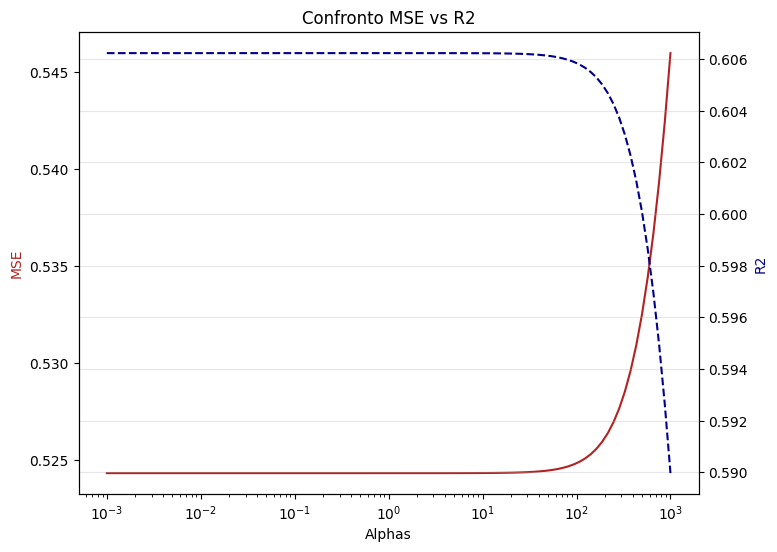

In [ ]:
# creiamo un plot dei valori trovati

fig, ax1 = plt.subplots(figsize=(8,6))

ax1.plot(alphas, mse_ridge, "-", color="firebrick")
ax1.set_xscale("log")
ax1.set_xlabel("Alphas")
ax1.set_ylabel("MSE", color="firebrick")

# il metodo twinx crea un secondo oggetto axis che condivide lo stesso asse x di un grafico esistente ma una y diversa

ax2 = ax1.twinx()
ax2.plot(alphas, r2_ridge, "--", color="darkblue")
ax2.set_ylabel("R2", color = "darkblue")

plt.title("Confronto MSE vs R2")
plt.grid(alpha=0.3)
plt.show()


In [21]:
# allenamento dell'oggetto RidgeCV con la cross validation usando alpha

alphas_cv = alphas
ridge_cv = RidgeCV(alphas = alphas, store_cv_results = True)
ridge_cv.fit(X_scaled, y)

print(f"Alpha RidgeCV:\t{ridge_cv.alpha_:.4f}")

y_pred_cv = ridge_cv.predict(X_scaled)
mse_cv = mean_squared_error(y, y_pred_cv)
r2_cv = r2_score(y, y_pred_cv)

print(f"MSE:\t{mse_cv:.4f}\nR2:\t{r2_cv:.4f}")


Alpha RidgeCV:	30.5386
MSE:	0.5244
R2:	0.6062


In [24]:
# verifichiamo qual è l'alpha ottimale

best_idx_man = np.argmin(mse_ridge)
best_alpha_man = alphas[best_idx_man]
best_mse_man = mse_ridge[best_idx_man]
best_r2_man = r2_ridge[best_idx_man]

print(f"Alpha Ridge:\t{best_alpha_man:.4f}\nMSE:\t{best_mse_man:.4f}\nR2:\t{best_r2_man:.4f}")

Alpha Ridge:	0.0010
MSE:	0.5243
R2:	0.6062


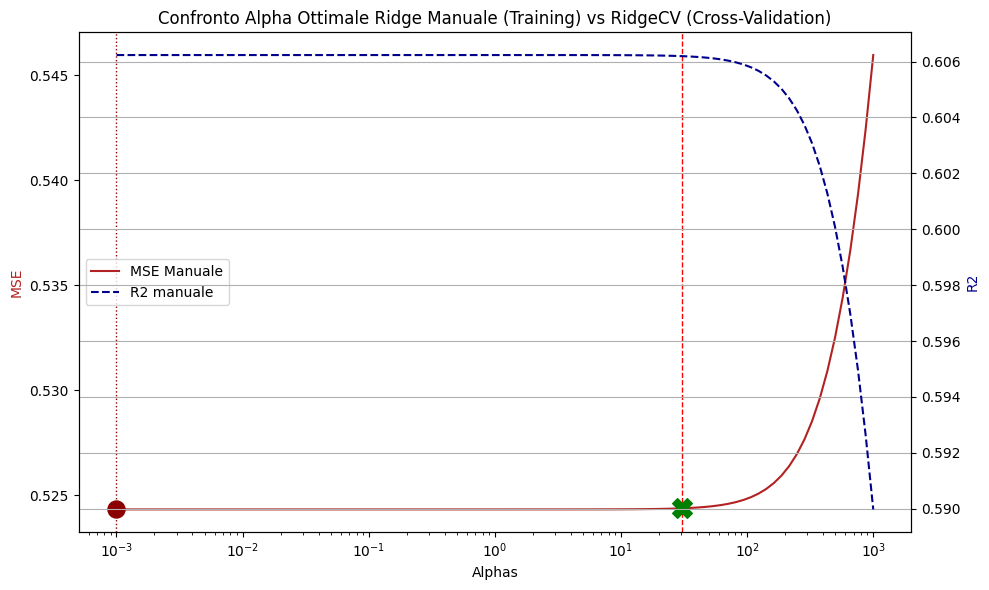

In [29]:
# plot di ridge andando a vedere l'alpha ottimale trovato manualmente che con la cross validation

fig, ax1 = plt.subplots(figsize=(10,6))

l1 = ax1.plot(alphas, mse_ridge, "-", color="firebrick", label = "MSE Manuale")
ax1.set_xscale("log")
ax1.set_xlabel("Alphas")
ax1.set_ylabel("MSE", color="firebrick")

# scatter plot degli alpha manuali
ax1.scatter(best_alpha_man, best_mse_man, color="darkred", s=150, zorder=5, label=f"n_manuale{best_alpha_man:.4f}")
ax1.axvline(best_alpha_man, color="darkred", linestyle=":", linewidth=1)

# scatter plot dell'alpha trovato con la cross validation
ax1.scatter(ridge_cv.alpha_, mean_squared_error(y, ridge_cv.predict(X_scaled)),
            color = "green", marker = "X", s=200, zorder=5,
            label = f"alpha Ridge={ridge_cv.alpha_:.4f}")
ax1.axvline(ridge_cv.alpha_, color="red", linestyle="--", linewidth=1)

ax2 = ax1.twinx()
l2 = ax2.plot(alphas, r2_ridge, "--", color="darkblue", label="R2 manuale")
ax2.set_ylabel("R2", color="darkblue")

plt.title(f"Confronto Alpha Ottimale Ridge Manuale (Training) vs RidgeCV (Cross-Validation)")
plt.grid()

lines = l1+l2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc = "center left")

plt.tight_layout()
plt.show()

Quello a sinistra è l'alpha ottimale, che si trova facendo il minimo di MSE e il massimo di r2. 
Come vediamo però c'è una grande distanza con l'alpha ottimale rappresentato con la x e trovato con la cross-validation. 
I valori di r2 e MSE non hanno grandi variazioni fino a quando alpha = 100